# Homework 07: Outliers and Risk Assumptions

This notebook detects extreme daily returns and compares model sensitivity under all-data, IQR-filtered, and winsorized treatments.

In [1]:
# Packages used: numpy, pandas, matplotlib, and scikit-learn

## 1. Generate the Dataset

Five large May shocks are added to a reproducible business-day return series. The second return series is correlated with the first. A named seed (`RANDOM_SEED = 17`) makes every simulated value reproducible.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

RAW = Path('data/raw')
PROCESSED = Path('data/processed')
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 17
dates = pd.date_range('2022-01-03', '2022-06-10', freq='B')
rng = np.random.default_rng(RANDOM_SEED)
returns = rng.normal(0, 0.01, len(dates))
returns[dates < '2022-05-01'] -= 0.0015
shocks = {
    '2022-05-02': 0.1748425,
    '2022-05-03': -0.1682580,
    '2022-05-06': -0.1966722,
    '2022-05-09': 0.2124022,
    '2022-05-12': -0.1787293,
}
for date, value in shocks.items():
    returns[np.where(dates == pd.Timestamp(date))[0][0]] = value

df = pd.DataFrame({
    'date': dates,
    'daily_return': returns,
    'daily_return_2': returns * 0.6 + rng.normal(0, 0.005, len(dates)),
})
raw_path = RAW / 'outliers_homework.csv'
df.to_csv(raw_path, index=False)
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.009513,0.007771
1,2022-01-04,0.001884,-0.000414
2,2022-01-05,-0.006900,-0.017307
3,2022-01-06,-0.014102,-0.007351
4,2022-01-07,-0.020446,-0.013652


## 2. Detect and Flag Outliers

IQR is the primary method because returns can be heavy-tailed and need not be normally distributed. A 3-sigma flag is included as a comparison. Both methods validate parameters and leave missing observations unflagged.

In [3]:
df = pd.read_csv(raw_path, parse_dates=['date'])
df['outlier_iqr'] = detect_outliers_iqr(df['daily_return'], k=1.5)
df['outlier_zscore'] = detect_outliers_zscore(df['daily_return'], threshold=3.0)
pd.DataFrame({
    'flagged_count': df[['outlier_iqr', 'outlier_zscore']].sum(),
    'flagged_share': df[['outlier_iqr', 'outlier_zscore']].mean(),
})

,flagged_count,flagged_share
outlier_iqr,5,0.043478
outlier_zscore,5,0.043478


## 3. Visual Comparison

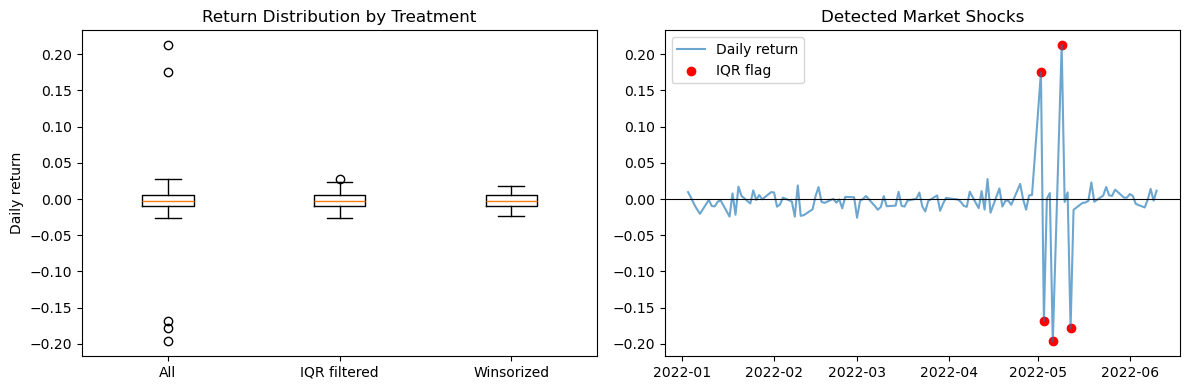

In [4]:
winsorized_return = winsorize_series(df['daily_return'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([df['daily_return'], df.loc[~df['outlier_iqr'], 'daily_return'], winsorized_return],
                tick_labels=['All', 'IQR filtered', 'Winsorized'])
axes[0].set_title('Return Distribution by Treatment')
axes[0].set_ylabel('Daily return')

axes[1].plot(df['date'], df['daily_return'], alpha=0.65, label='Daily return')
axes[1].scatter(df.loc[df['outlier_iqr'], 'date'], df.loc[df['outlier_iqr'], 'daily_return'],
                color='red', label='IQR flag')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Detected Market Shocks')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis

The same regression is fitted under three treatments. This tests whether conclusions about the relationship between the two return series depend on a small number of extreme observations.

In [5]:
def fit_metrics(frame: pd.DataFrame, x_col: str, y_col: str) -> dict[str, float]:
    """Fit a one-variable linear model and return comparable in-sample metrics."""
    model = LinearRegression().fit(frame[[x_col]], frame[y_col])
    prediction = model.predict(frame[[x_col]])
    return {
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': model.score(frame[[x_col]], frame[y_col]),
        'mae': mean_absolute_error(frame[y_col], prediction),
    }

filtered = df.loc[~df['outlier_iqr'], ['daily_return', 'daily_return_2']].copy()
winsorized = df[['daily_return', 'daily_return_2']].copy()
winsorized['daily_return'] = winsorize_series(winsorized['daily_return'])
winsorized['daily_return_2'] = winsorize_series(winsorized['daily_return_2'])

results = pd.DataFrame({
    'all': fit_metrics(df, 'daily_return', 'daily_return_2'),
    'filtered_iqr': fit_metrics(filtered, 'daily_return', 'daily_return_2'),
    'winsorized': fit_metrics(winsorized, 'daily_return', 'daily_return_2'),
}).T
results.to_csv(PROCESSED / 'outlier_sensitivity.csv')
results

,slope,intercept,r2,mae
all,0.581999,-0.000467,0.958325,0.003734
filtered_iqr,0.565447,-0.000398,0.603646,0.003771
winsorized,0.597067,-0.000296,0.656127,0.003643


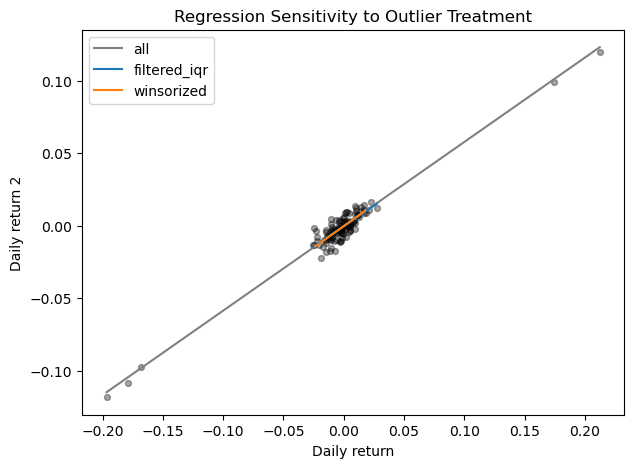

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'all': 'gray', 'filtered_iqr': 'tab:blue', 'winsorized': 'tab:orange'}
treatments = {
    'all': df[['daily_return', 'daily_return_2']],
    'filtered_iqr': filtered,
    'winsorized': winsorized,
}
for name, frame in treatments.items():
    model = LinearRegression().fit(frame[['daily_return']], frame['daily_return_2'])
    x_line = pd.DataFrame({
        'daily_return': np.linspace(frame['daily_return'].min(), frame['daily_return'].max(), 100)
    })
    ax.plot(x_line['daily_return'], model.predict(x_line), color=colors[name], label=name)
ax.scatter(df['daily_return'], df['daily_return_2'], s=18, alpha=0.35, color='black')
ax.set(title='Regression Sensitivity to Outlier Treatment', xlabel='Daily return', ylabel='Daily return 2')
ax.legend()
plt.show()

## 5. Reflection

I used the 1.5-IQR rule as the main detector because financial returns may be heavy-tailed, while the 3-sigma method relies more heavily on a normal-distribution interpretation. Winsorization at 5% and 95% limits influence without deleting dates.

The five flagged shock days raise $R^2$ from 0.604 after IQR filtering to 0.958 in the full sample. The slope changes less, from 0.565 to 0.582, and MAE remains near 0.0037. This means the shocks strongly improve the apparent fit but do not completely determine the estimated direction. They may be genuine market events rather than errors, so deleting them could understate tail risk. The raw observations are preserved and all three treatments are reported.